### Building a simple workflow graph using langgraph

In [3]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info: str

#### Creating Nodes

In [4]:
def start_play(state: State):
    print("Node start_play is called")
    return {"graph_info": state["graph_info"] + "->start_play"}


def cricket(state: State):
    print("Node cricket is called")
    return {"graph_info": state["graph_info"] + "->cricket"}


def basketball(state: State):
    print("Node basketball is called")
    return {"graph_info": state["graph_info"] + "->basketball"}

#### Creating conditonal edges

In [ ]:
import random
from typing import Literal
    

def select_sport(state: State) -> Literal["cricket", "basketball"]:
    print("conditional edge select_sport is called")

    if random.random() > 0.5:
        return "cricket"
    else:
        return "basketball"

#### Construct our graph

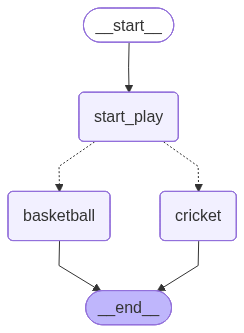

In [17]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

## build graph
graph = StateGraph(State)

## Adding the nodes
graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("basketball", basketball)

## schedule the flow of graph
graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", select_sport)
graph.add_edge("cricket", END)
graph.add_edge("basketball", END)

## compile the graph
builder = graph.compile()

## view the graph
display(Image(builder.get_graph().draw_mermaid_png()))

#### Graph invocation

In [22]:
builder.invoke({"graph_info": "Hey my name is dennis"})

Node start_play is called
conditional node select_sport is called
Node cricket is called


{'graph_info': 'Hey my name is dennis->start_play->cricket'}